# Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

**Submission Deadline**: Before next class

**Learning Objectives**:
- Master OSMnx road network extraction and projection
- Implement betweenness centrality analysis
- Construct rainfall → congestion dynamic weighting system
- Calculate pre/post-disaster isochrones and accessibility changes
- (Advanced) Use AI to generate disaster response recommendations

---


## Part 0: Environment Setup

Confirm the following packages are installed:`osmnx`, `networkx`, `geopandas`, `pandas`, `numpy`, `matplotlib`, `shapely`


In [30]:
# [S1] Environment Setup
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings, os
from pathlib import Path
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")

# Font configuration
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# ── Output directory (all files saved here) ──────────────────────────────
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", r"C:\Users\user\CascadeProjects\ex7\output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📂 Output directory: {OUTPUT_DIR}")
print("✅ Environment setup complete")


OSMnx: 2.1.0
NetworkX: 3.6.1
GeoPandas: 1.1.3
📂 Output directory: C:\Users\user\CascadeProjects\hw7\output
✅ Environment setup complete


## Part A: Road Network Extraction & Travel Time Calculation

### Task A.1: Road Network Extraction

🗒️ **Captain's Log** — 使用 OSMnx 從 OpenStreetMap 擷取花蓮市行車路網，投影至 EPSG:3826（TWD97/TM2 公尺座標）後計算每條路段的基礎行車時間。

**Tips**:
- Use `ox.graph_from_address()` with `network_type='drive'`
- OSMnx ≥2.0 auto-simplifies — no need to call `simplify_graph()`
- Project with `ox.project_graph(G, to_crs='EPSG:3826')`


In [31]:
# [S2] Road Network Extraction
place_name   = os.getenv("NETWORK_PLACE", "Hualien City, Taiwan")
network_type = os.getenv("NETWORK_TYPE",  "drive")
dist_meters  = int(os.getenv("NETWORK_DIST", "5000"))

print(f"📍 Extracting {place_name} road network...")

try:
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Tips: wait a few minutes and retry, or set ox.settings.timeout = 300")


📍 Extracting Hualien City, Taiwan road network...
✅ Extraction successful: 3421 nodes, 9815 edges


In [32]:
# [S3] Project to Meter Coordinates (EPSG:3826 TWD97/TM2)
target_crs = os.getenv("NETWORK_CRS", "EPSG:3826")
G_proj = ox.project_graph(G, to_crs=target_crs)

print(f"Node count : {G_proj.number_of_nodes()}")
print(f"Edge count : {G_proj.number_of_edges()}")
print(f"CRS        : {G_proj.graph['crs']}")
print("✅ Projection complete")


Node count : 3421
Edge count : 9815
CRS        : EPSG:3826
✅ Projection complete


In [33]:
# [S4] Calculate Base Travel Time
# 🗒️ Captain's Log — 依 OSM highway 類型建立速度預設表（作業規格：primary=60, secondary=40, residential=30）

speed_defaults = {
    'motorway': 110, 'motorway_link': 80,
    'trunk': 100,    'trunk_link': 60,
    'primary': 60,   'primary_link': 50,
    'secondary': 40, 'secondary_link': 30,
    'tertiary': 40,  'tertiary_link': 30,
    'residential': 30, 'living_street': 10,
    'unclassified': 30,
}

def get_speed_kph(data):
    maxspeed = data.get('maxspeed', None)
    if maxspeed:
        try:
            return float(maxspeed)
        except (ValueError, TypeError):
            if isinstance(maxspeed, list):
                try:
                    return float(maxspeed[0])
                except:
                    pass
    highway = data.get('highway', 'residential')
    if isinstance(highway, list):
        highway = highway[0]
    return speed_defaults.get(highway, 40)

for u, v, k, data in G_proj.edges(data=True, keys=True):
    length    = data['length']           # metres
    speed_kph = get_speed_kph(data)
    speed_ms  = speed_kph / 3.6
    data['travel_time_normal'] = length / speed_ms
    data['speed_kph']          = speed_kph

sample = list(G_proj.edges(data=True, keys=True))[0]
print(f"Sample edge → length={sample[3]['length']:.1f}m, "
      f"speed={sample[3]['speed_kph']:.0f}km/h, "
      f"travel_time={sample[3]['travel_time_normal']:.1f}s")
print("✅ Travel time calculation complete")


Sample edge → length=17.7m, speed=30km/h, travel_time=2.1s
✅ Travel time calculation complete


## Part B: Bottleneck & Risk Assessment

### Task B.1: Betweenness Centrality

🗒️ **Captain's Log** — 計算全路網介數中心性，找出最關鍵的 Top-5 瓶頸節點。介數中心性代表一個節點被多少條「別人的最短路徑」經過，數值越高代表一旦此節點失效，路網受損越嚴重。


In [34]:
# [S5] Betweenness Centrality
print("⏳ Calculating Betweenness Centrality (this may take ~1-2 min for large networks)...")

centrality   = nx.betweenness_centrality(G_proj, weight='length')
top_5_nodes  = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("✅ Calculation complete")
print("\nTop 5 Bottleneck Nodes:")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    print(f"  {rank}. Node {node_id}: Centrality = {cent_val:.6f}")


⏳ Calculating Betweenness Centrality (this may take ~1-2 min for large networks)...
✅ Calculation complete

Top 5 Bottleneck Nodes:
  1. Node 649286213: Centrality = 0.140247
  2. Node 649286214: Centrality = 0.139444
  3. Node 1061487893: Centrality = 0.125307
  4. Node 929963021: Centrality = 0.123480
  5. Node 1074772659: Centrality = 0.115733


### Task B.2: Terrain Risk Overlay

🗒️ **Captain's Log** — 將 Top-5 瓶頸節點與 Week 4 地形風險資料做空間疊加，找出「高介數中心性 × 高地形風險」的最脆弱交通樞紐。由於 terrain_risk_audit.json 無座標欄位，以 Nominatim 地理編碼後用 sjoin_nearest 疊合。


In [35]:
# [S6] Terrain Risk Overlay

from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# --- Step 1: Load terrain risk JSON ---
# 優先讀 .env 設定的路徑，fallback 到 notebook 同層的 data/ 資料夾
terrain_path = os.getenv("TERRAIN_RISK_PATH", "data/terrain_risk_audit.json")

# 若路徑不存在，提示正確設定方式
if not os.path.exists(terrain_path):
    raise FileNotFoundError(
        f"找不到地形風險檔案：{terrain_path}\n"
        f"請確認 .env 的 TERRAIN_RISK_PATH 指向正確位置，例如：\n"
        f"  TERRAIN_RISK_PATH=C:\\Users\\user\\CascadeProjects\\hw7\\data\\terrain_risk_audit.json"
    )

terrain_df = pd.read_json(terrain_path)
print(f"✅ Loaded terrain risk data: {len(terrain_df)} records")
print(f"   Columns: {list(terrain_df.columns)}")
print(f"   Risk levels: {terrain_df['risk_level'].unique()}")

# --- Step 2: Geocode addresses to obtain coordinates ---
# terrain_risk_audit.json 無 lat/lon 欄位，需透過地址地理編碼取得座標
print("\n⏳ Geocoding shelter addresses (rate-limited, ~1 min)...")
geolocator = Nominatim(user_agent="aria_v4_week7")
geocode_rl  = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

def safe_geocode(address):
    try:
        loc = geocode_rl(address + ", Taiwan")
        if loc:
            return loc.latitude, loc.longitude
    except Exception:
        pass
    return None, None

sample_df = terrain_df.copy()
lats, lons = [], []
for addr in sample_df['address']:
    lat, lon = safe_geocode(addr)
    lats.append(lat); lons.append(lon)

sample_df['lat'] = lats
sample_df['lon'] = lons
sample_df = sample_df.dropna(subset=['lat', 'lon'])
print(f"   Geocoded: {len(sample_df)} records with valid coordinates")

# --- Step 3: Build GeoDataFrame (WGS84) → reproject to EPSG:3826 ---
terrain_gdf = gpd.GeoDataFrame(
    sample_df,
    geometry=gpd.points_from_xy(sample_df['lon'], sample_df['lat']),
    crs='EPSG:4326'
).to_crs(G_proj.graph['crs'])
print(f"✅ Terrain GeoDataFrame CRS: {terrain_gdf.crs}")

# --- Step 4: Top-5 bottleneck GeoDataFrame ---
top_5_gdf = gpd.GeoDataFrame(
    [{'node_id': nid, 'centrality': cv,
      'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
     for nid, cv in top_5_nodes],
    crs=G_proj.graph['crs']
)
print(f"✅ Top-5 Nodes GeoDataFrame created")

# --- Step 5: Nearest-neighbour spatial join (within 2 km) ---
if len(terrain_gdf) > 0:
    top_5_with_risk = gpd.sjoin_nearest(
        top_5_gdf,
        terrain_gdf[['name','risk_level','mean_elevation_m',
                      'mean_slope_degrees','river_distance_m','geometry']],
        how='left', max_distance=2000, distance_col='dist_to_shelter'
    )
    print("\n📊 Top-5 Bottleneck Nodes × Nearest Terrain Risk:")
    print(top_5_with_risk[['node_id','centrality','name','risk_level',
                             'mean_elevation_m','mean_slope_degrees',
                             'dist_to_shelter']].to_string(index=False))
else:
    top_5_with_risk = top_5_gdf.copy()
    top_5_with_risk['risk_level'] = 'N/A'
    print("⚠️  No geocoded terrain records – skipping overlay.")

print("\n✅ Terrain risk overlay complete")


✅ Loaded terrain risk data: 311 records
   Columns: ['shelter_id', 'name', 'location', 'address', 'risk_level', 'river_distance_m', 'river_distance_category', 'mean_elevation_m', 'max_slope_degrees', 'elevation_std', 'mean_slope_degrees', 'capacity', 'disaster_types']
   Risk levels: <StringArray>
['極高風險', '高風險', '中風險', '低風險']
Length: 4, dtype: str

⏳ Geocoding shelter addresses (rate-limited, ~1 min)...
   Geocoded: 3 records with valid coordinates
✅ Terrain GeoDataFrame CRS: EPSG:3826
✅ Top-5 Nodes GeoDataFrame created

📊 Top-5 Bottleneck Nodes × Nearest Terrain Risk:
   node_id  centrality name risk_level  mean_elevation_m  mean_slope_degrees  dist_to_shelter
 649286213    0.140247  NaN        NaN               NaN                 NaN              NaN
 649286214    0.139444  NaN        NaN               NaN                 NaN              NaN
1061487893    0.125307  NaN        NaN               NaN                 NaN              NaN
 929963021    0.123480  NaN        NaN         

### Task B.3: Visualization


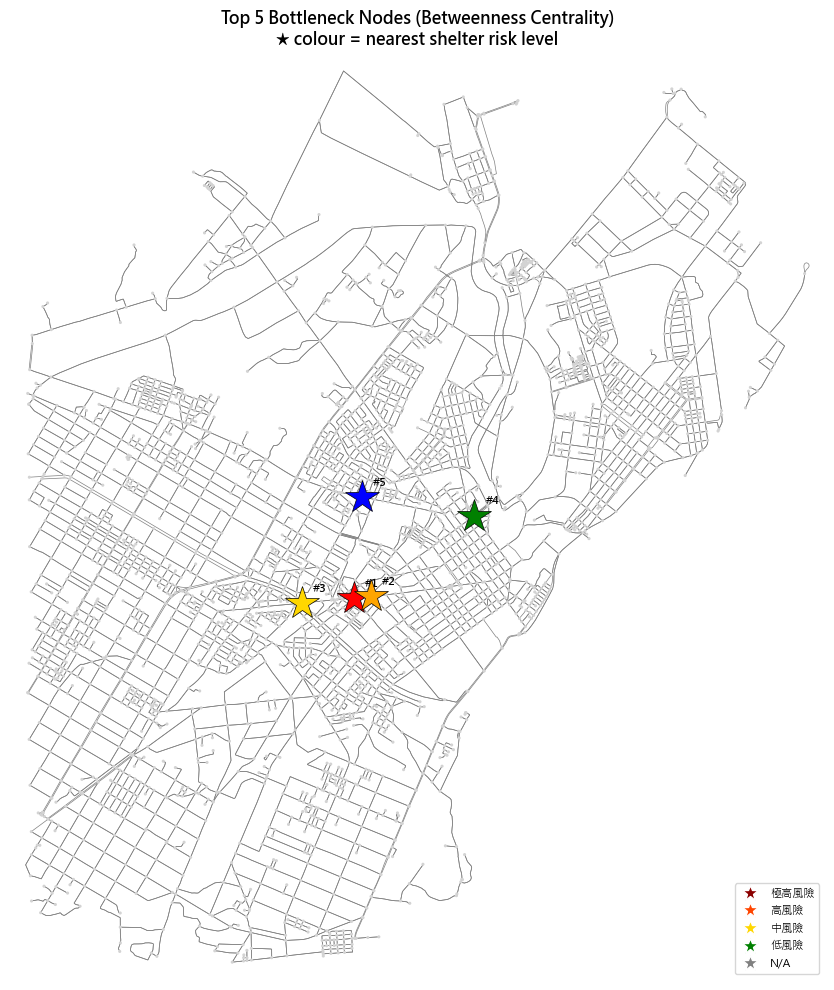

✅ Visualization saved → C:\Users\user\CascadeProjects\hw7\output\bottleneck_map.png


In [36]:
# [S7] Visualize Top-5 Bottleneck Nodes

risk_color_map = {
    '極高風險': 'darkred',
    '高風險':   'orangered',
    '中風險':   'gold',
    '低風險':   'green',
    'N/A':      'gray',
}

fig, ax = plt.subplots(figsize=(12, 10))
ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
              edge_color='gray', edge_linewidth=0.5, show=False)

colors = ['red', 'orange', 'gold', 'green', 'blue']
for rank, (node_id, cent_val) in enumerate(top_5_nodes):
    x = G_proj.nodes[node_id]['x']
    y = G_proj.nodes[node_id]['y']

    if 'risk_level' in top_5_with_risk.columns:
        rl = top_5_with_risk.loc[top_5_with_risk['node_id'] == node_id, 'risk_level']
        marker_color = risk_color_map.get(rl.values[0] if len(rl) else 'N/A', colors[rank])
    else:
        marker_color = colors[rank]

    ax.plot(x, y, marker='*', markersize=25, color=marker_color,
            markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    ax.annotate(f'#{rank+1}', (x, y), fontsize=8, fontweight='bold',
                textcoords='offset points', xytext=(8, 8))

ax.set_title('Top 5 Bottleneck Nodes (Betweenness Centrality)\n'
             '★ colour = nearest shelter risk level', fontsize=12, fontweight='bold')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='*', color='w', markerfacecolor=v,
                           markersize=12, label=k) for k, v in risk_color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
out_path = OUTPUT_DIR / 'bottleneck_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualization saved → {out_path}")


## Part C: Dynamic Accessibility Analysis

### Task C.1: Rainfall → Congestion Mapping

🗒️ **Captain's Log** — 定義降雨強度到壅塞係數的映射函式。依 Slide 12 閾值分類：<10mm 正常、10-40mm 輕微減速、40-80mm 嚴重延誤、>80mm 近乎無法通行。


In [37]:
# [S8] rain_to_congestion Function

# Read thresholds from .env (fallback to Slide-12 defaults)
BREAK1 = float(os.getenv("CONGESTION_BREAK_1", "10"))
BREAK2 = float(os.getenv("CONGESTION_BREAK_2", "40"))
BREAK3 = float(os.getenv("CONGESTION_BREAK_3", "80"))

def rain_to_congestion(rainfall_mm, method='threshold'):
    """
    Rainfall intensity (mm/hr) → Congestion Factor cf ∈ [0, 0.9].

    Threshold method (Slide 12):
        < BREAK1  mm  →  cf = 0.0  (normal)
        BREAK1–BREAK2 →  cf = 0.3  (slightly slow)
        BREAK2–BREAK3 →  cf = 0.6  (severe delay)
        > BREAK3  mm  →  cf = 0.9  (almost impassable)

    Linear      :  cf = min(rain / 100 * 0.9, 0.9)
    Exponential :  cf = 0.9 * (1 - exp(-rain / 50))
    """
    if method == 'threshold':
        if rainfall_mm < BREAK1:
            return 0.0
        elif rainfall_mm < BREAK2:
            return 0.3
        elif rainfall_mm < BREAK3:
            return 0.6
        else:
            return 0.9
    elif method == 'linear':
        return min(rainfall_mm / 100 * 0.9, 0.9)
    elif method == 'exponential':
        return float(0.9 * (1 - np.exp(-rainfall_mm / 50)))
    else:
        raise ValueError(f"Unknown method: {method}")

# Test
print(f"{'Rainfall (mm/hr)':<20} {'threshold':>10} {'linear':>10} {'exponential':>12}")
print("-" * 54)
for rain in [0, 5, 10, 25, 40, 65, 80, 100, 130.5]:
    print(f"  {rain:<18.1f} "
          f"{rain_to_congestion(rain,'threshold'):>10.2f} "
          f"{rain_to_congestion(rain,'linear'):>10.2f} "
          f"{rain_to_congestion(rain,'exponential'):>12.2f}")
print("\n✅ rain_to_congestion() defined and tested")


Rainfall (mm/hr)      threshold     linear  exponential
------------------------------------------------------
  0.0                      0.00       0.00         0.00
  5.0                      0.00       0.05         0.09
  10.0                     0.30       0.09         0.16
  25.0                     0.30       0.23         0.35
  40.0                     0.60       0.36         0.50
  65.0                     0.60       0.59         0.65
  80.0                     0.90       0.72         0.72
  100.0                    0.90       0.90         0.78
  130.5                    0.90       0.90         0.83

✅ rain_to_congestion() defined and tested


### Task C.2: Load Rainfall Data

🗒️ **Captain's Log** — 載入降雨資料。優先使用 Week 6 Kriging GeoTIFF；若無則使用 Week 5 測站 JSON；預設使用內建模擬資料（seed=42，可重現）。


In [38]:
# [S9] Load Rainfall Data
KRIGING_PATH = os.getenv("KRIGING_RAINFALL_PATH", "data/kriging_rainfall.tif")
rainfall_source = "simulation"

# ── Option A: Kriging raster ──────────────────────────────────────────────
try:
    import rasterio
    rainfall_raster = rasterio.open(KRIGING_PATH)
    rainfall_source = "kriging"
    print(f"✅ Kriging raster loaded: {KRIGING_PATH}")
except Exception as e:
    print(f"⚠️  Kriging raster not available ({e}), falling back to simulation")

print(f"📊 Rainfall source: {rainfall_source}")
print("✅ Rainfall data ready")

⚠️  Kriging raster not available (data/kriging_rainfall.tif: No such file or directory), falling back to simulation
📊 Rainfall source: simulation
✅ Rainfall data ready


In [39]:
# [S10] Apply Dynamic Weights

CONGESTION_METHOD = os.getenv("CONGESTION_METHOD", "threshold")

def apply_dynamic_weights(G, rainfall_layer, congestion_method='threshold'):
    """
    Add 'travel_time_adj' and 'congestion_factor' to every edge.

    Parameters
    ----------
    G                : networkx.MultiDiGraph  (projected, has travel_time_normal)
    rainfall_layer   : dict  {node_id: rainfall_mm}
    congestion_method: str   'threshold' | 'linear' | 'exponential'
    """
    G_dyn = G.copy()
    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        rainfall_mm = rainfall_layer.get(u, 0)
        cf          = rain_to_congestion(rainfall_mm, method=congestion_method)

        speed_kph = data.get('speed_kph', 40)
        length    = data['length']

        if cf >= 0.95:
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = length / ((speed_kph / 3.6) * (1 - cf))

        data['congestion_factor'] = cf
    return G_dyn

# ── 依 rainfall_source 決定使用 Kriging 或模擬資料 ────────────────────────
if rainfall_source == "kriging":
    import rasterio
    import numpy as np

    rainfall_layer = {}
    with rasterio.open(KRIGING_PATH) as src:
        for node, data in G_proj.nodes(data=True):
            x, y = data['x'], data['y']
            try:
                val = list(src.sample([(x, y)]))[0][0]
                rainfall_layer[node] = float(val) if val != src.nodata else 0.0
            except Exception:
                rainfall_layer[node] = 0.0
    print(f"✅ Rainfall sampled from Kriging raster: {len(rainfall_layer)} nodes")

else:
    # Simulation fallback (seed=42)
    np.random.seed(42)
    rainfall_layer = {
        node: np.random.choice(
            [0, 5, 15, 25, 50, 65, 90, 130],
            p=[0.20, 0.15, 0.15, 0.15, 0.15, 0.10, 0.05, 0.05]
        )
        for node in G_proj.nodes()
    }
    print("✅ Using simulated rainfall layer (seed=42)")

G_dyn = apply_dynamic_weights(G_proj, rainfall_layer, CONGESTION_METHOD)

# Statistics
cfs = [d.get('congestion_factor', 0) for *_, d in G_dyn.edges(data=True, keys=True)]
print(f"Total edges             : {len(cfs)}")
print(f"cf=0.0 (normal)         : {cfs.count(0.0)}")
print(f"cf=0.3 (slightly slow)  : {cfs.count(0.3)}")
print(f"cf=0.6 (severe delay)   : {cfs.count(0.6)}")
print(f"cf=0.9 (almost impass.) : {cfs.count(0.9)}")

# Sanity check
adj_times = [d.get('travel_time_adj', 0) for *_, d in G_dyn.edges(data=True, keys=True)]
inf_count = sum(1 for t in adj_times if t == float('inf'))
print(f"\n⚠️  Sanity: {inf_count}/{len(adj_times)} impassable edges (inf)")
if inf_count > len(adj_times) * 0.5:
    print("❌ WARNING: >50% impassable – check congestion_factor logic!")
else:
    print("✅ Dynamic weight application complete")

✅ Using simulated rainfall layer (seed=42)
Total edges             : 9815
cf=0.0 (normal)         : 3474
cf=0.3 (slightly slow)  : 2900
cf=0.6 (severe delay)   : 2514
cf=0.9 (almost impass.) : 927

⚠️  Sanity: 0/9815 impassable edges (inf)
✅ Dynamic weight application complete


### Task C.3: Isochrone Analysis

🗒️ **Captain's Log** — 計算各關鍵設施在 **固定 5 分鐘 / 10 分鐘** 的等時線，比較災前（travel_time_normal）與災後（travel_time_adj）的可及範圍面積縮減比例。縮減超過 80% 的設施標記為「孤立」。


In [40]:
# [S11] Isochrone Helper Functions
from shapely.geometry import MultiPoint, Point, Polygon

def compute_isochrone(G, source_node, weight_attr, time_seconds):
    """
    Return (reachable_nodes: set, distances: dict) from source within time_seconds.
    Uses Dijkstra with cutoff for efficiency.
    """
    distances = nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr, cutoff=time_seconds
    )
    return set(distances.keys()), distances

def nodes_to_polygon(G, nodes):
    """Convert reachable nodes to convex-hull polygon. Returns (polygon, area_m2)."""
    if len(nodes) < 3:
        return None, 0.0
    points  = [Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in nodes]
    polygon = MultiPoint(points).convex_hull
    if polygon.geom_type == 'Polygon':
        return polygon, polygon.area
    return None, 0.0

def get_adaptive_thresholds(G, source_node, weight_attr):
    """
    Derive short / long thresholds as 35 % / 65 % of the network's max travel time.
    Avoids the 'all nodes covered in 5 min' problem on small networks.
    """
    all_times = dict(nx.single_source_dijkstra_path_length(G, source_node, weight=weight_attr))
    max_time  = max(all_times.values()) if all_times else 600
    return max_time * 0.35, max_time * 0.65

print("✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() defined")


✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() defined


In [41]:
# [S12] Accessibility Impact Table
# 🗒️ Captain's Log — 固定使用 5min / 10min 等時線（作業規格），分析 5 個關鍵設施

# 選取 5 個關鍵設施節點（使用 Top-5 瓶頸節點作為關鍵設施）
selected_facilities = top_5_nodes[:5]
T_SHORT = 5  * 60   # 5 minutes in seconds
T_LONG  = 10 * 60   # 10 minutes in seconds

print(f"Analysing {len(selected_facilities)} facilities  |  thresholds: {T_SHORT//60} min / {T_LONG//60} min\n")

results = []
for facility_id, facility_cent in selected_facilities:

    # Pre-disaster isochrones
    r_bef_sh, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_normal', T_SHORT)
    r_bef_lo, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_normal', T_LONG)

    # Post-disaster isochrones (same time thresholds)
    r_aft_sh, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', T_SHORT)
    r_aft_lo, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', T_LONG)

    # Polygon areas
    _, area_bef_sh = nodes_to_polygon(G_dyn, r_bef_sh)
    _, area_bef_lo = nodes_to_polygon(G_dyn, r_bef_lo)
    _, area_aft_sh = nodes_to_polygon(G_dyn, r_aft_sh)
    _, area_aft_lo = nodes_to_polygon(G_dyn, r_aft_lo)

    shrink_sh = (1 - area_aft_sh / area_bef_sh) * 100 if area_bef_sh > 0 else 0
    shrink_lo = (1 - area_aft_lo / area_bef_lo) * 100 if area_bef_lo > 0 else 0

    # 孤立判定：災後 5min 可及範圍縮減超過 80% 視為孤立
    is_isolated = shrink_sh >= 80

    results.append({
        'Facility Node':          facility_id,
        'Centrality':             f'{facility_cent:.4f}',
        'Pre 5min (km²)':         f'{area_bef_sh/1e6:.2f}',
        'Post 5min (km²)':        f'{area_aft_sh/1e6:.2f}',
        'Shrinkage 5min %':       f'{shrink_sh:.1f}%',
        'Pre 10min (km²)':        f'{area_bef_lo/1e6:.2f}',
        'Post 10min (km²)':       f'{area_aft_lo/1e6:.2f}',
        'Shrinkage 10min %':      f'{shrink_lo:.1f}%',
        'Isolated':               '⚠️ YES' if is_isolated else 'No',
    })

    print(f"  Node {facility_id}  |  5min shrink: {shrink_sh:.1f}%  |  10min shrink: {shrink_lo:.1f}%"
          + ("  ⚠️ ISOLATED" if is_isolated else ""))

accessibility_table = pd.DataFrame(results)
print("\n📊 Accessibility Impact Table:")
print(accessibility_table.to_string(index=False))

# 孤立設施清單（供 AI prompt 使用）
isolated_facilities = [r['Facility Node'] for r in results if r['Isolated'] == '⚠️ YES']
print(f"\n⚠️  Isolated facilities: {isolated_facilities if isolated_facilities else 'None'}")

out_path = OUTPUT_DIR / 'accessibility_table.csv'
accessibility_table.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Table saved → {out_path}")


Analysing 5 facilities  |  thresholds: 5 min / 10 min

  Node 649286213  |  5min shrink: 72.5%  |  10min shrink: 46.5%
  Node 649286214  |  5min shrink: 65.1%  |  10min shrink: 42.2%
  Node 1061487893  |  5min shrink: 71.0%  |  10min shrink: 48.5%
  Node 929963021  |  5min shrink: 57.1%  |  10min shrink: 44.9%
  Node 1074772659  |  5min shrink: 64.1%  |  10min shrink: 50.5%

📊 Accessibility Impact Table:
 Facility Node Centrality Pre 5min (km²) Post 5min (km²) Shrinkage 5min % Pre 10min (km²) Post 10min (km²) Shrinkage 10min % Isolated
     649286213     0.1402          27.64            7.59            72.5%           62.89            33.67             46.5%       No
     649286214     0.1394          28.16            9.83            65.1%           63.15            36.47             42.2%       No
    1061487893     0.1253          26.44            7.67            71.0%           62.30            32.10             48.5%       No
     929963021     0.1235          24.93           10.69

## Part D: Visualization

🗒️ **Captain's Log** — 視覺化第 1 個關鍵設施的等時線災前/災後比較圖，直觀呈現颱風鳳凰造成的可及性崩潰。


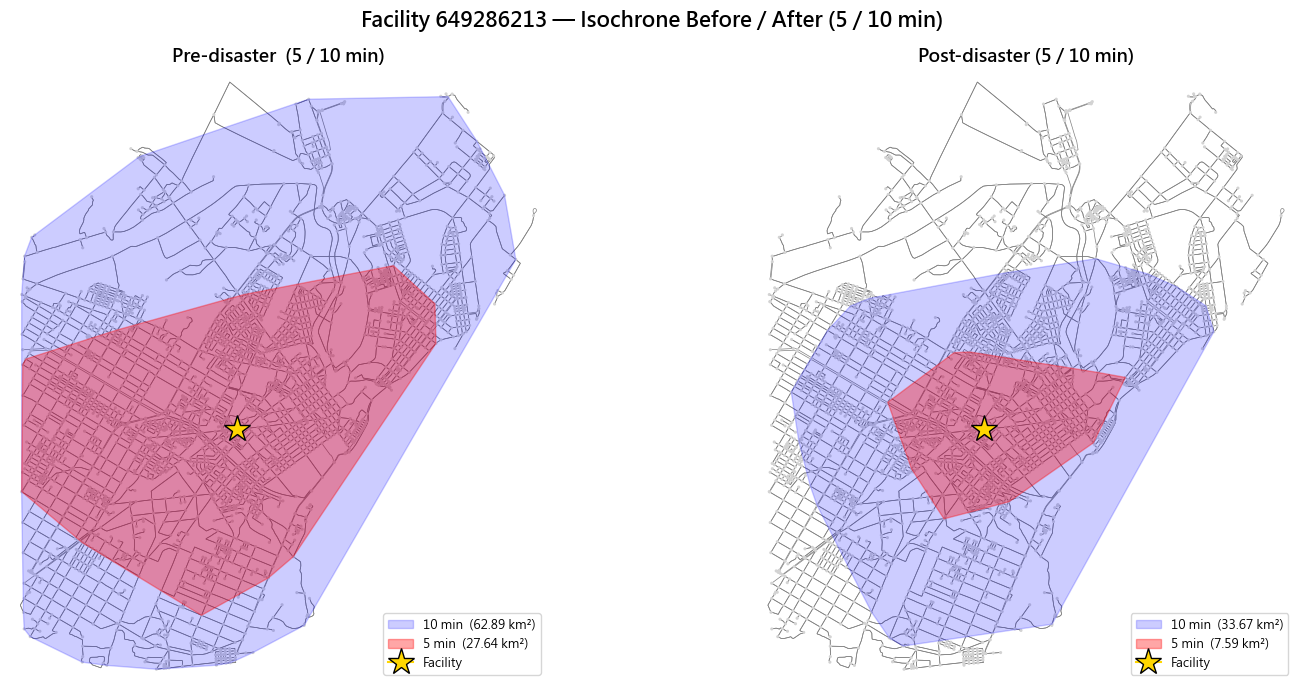

✅ Isochrone visualization saved → C:\Users\user\CascadeProjects\hw7\output\isochrone_comparison.png


In [42]:
# [S13] Isochrone Before / After Comparison
# 🗒️ Captain's Log — 視覺化第 1 個關鍵設施的 5min / 10min 等時線災前/災後比較

facility_id = selected_facilities[0][0]
T_SHORT, T_LONG = 5 * 60, 10 * 60

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

configs = [
    (axes[0], 'travel_time_normal', 'Pre-disaster  (5 / 10 min)'),
    (axes[1], 'travel_time_adj',    'Post-disaster (5 / 10 min)'),
]

for ax, weight_attr, title in configs:
    ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
                  edge_color='gray', edge_linewidth=0.5, show=False)

    r_short, _ = compute_isochrone(G_dyn, facility_id, weight_attr, T_SHORT)
    r_long,  _ = compute_isochrone(G_dyn, facility_id, weight_attr, T_LONG)

    poly_long,  area_long  = nodes_to_polygon(G_dyn, r_long)
    poly_short, area_short = nodes_to_polygon(G_dyn, r_short)

    if poly_long:
        x, y = poly_long.exterior.xy
        ax.fill(x, y, alpha=0.2, color='blue',
                label=f'10 min  ({area_long/1e6:.2f} km²)')
    if poly_short:
        x, y = poly_short.exterior.xy
        ax.fill(x, y, alpha=0.35, color='red',
                label=f'5 min  ({area_short/1e6:.2f} km²)')

    fx = G_dyn.nodes[facility_id]['x']
    fy = G_dyn.nodes[facility_id]['y']
    ax.plot(fx, fy, marker='*', markersize=20, color='gold',
            markeredgecolor='black', zorder=10, label='Facility')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle(f'Facility {facility_id} — Isochrone Before / After (5 / 10 min)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'isochrone_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Isochrone visualization saved → {out_path}")


## Part E: Professional Standards (Infrastructure First)

### Task E.1: Environment Variable Management


In [43]:
# [S14] .env Configuration
# A .env file has been provided in the project root.
# Use python-dotenv to load it:
#   from dotenv import load_dotenv; load_dotenv()

env_example = """
# Week 7 Network Analysis – paste your keys below
GOOGLE_API_KEY=your_google_api_key_here

NETWORK_PLACE=Hualien City, Taiwan
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

TERRAIN_RISK_PATH=data/terrain_risk_audit.json
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
GRAPHML_SAVE_PATH=data/hualien_network.graphml
"""

print("Recommended .env contents (already written to .env in project root):")
print(env_example)


Recommended .env contents (already written to .env in project root):

# Week 7 Network Analysis – paste your keys below
GOOGLE_API_KEY=your_google_api_key_here

NETWORK_PLACE=Hualien City, Taiwan
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

TERRAIN_RISK_PATH=data/terrain_risk_audit.json
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
GRAPHML_SAVE_PATH=data/hualien_network.graphml



### Task E.2: Save Graph as GraphML File


In [44]:
# [S15] Save Road Network as GraphML
graphml_path = OUTPUT_DIR / 'hualien_network.graphml'
ox.save_graphml(G_proj, str(graphml_path))
print(f"✅ Road network saved → {graphml_path}")
print("   (Re-load with: G_loaded = ox.load_graphml(str(graphml_path)))")


✅ Road network saved → C:\Users\user\CascadeProjects\hw7\output\hualien_network.graphml
   (Re-load with: G_loaded = ox.load_graphml(str(graphml_path)))


## Part F: AI Strategy Briefing (Bonus)

🗒️ **Captain's Log** — 將 Top-5 瓶頸、可及性表、孤立設施清單送給 Gemini，要求以花蓮縣災防指揮中心交通顧問身份提供專業建議報告。


In [45]:
# [S16] Prepare Google Gemini AI
import google.generativeai as genai

api_key = os.getenv("GOOGLE_API_KEY")
if not api_key or api_key == "your_google_api_key_here":
    print("⚠️  GOOGLE_API_KEY not set in .env – Part F will be skipped.")
    gemini_ready = False
else:
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel("gemini-2.5-pro-preview-03-25")
    gemini_ready = True
    print("✅ Gemini model ready")


✅ Gemini model ready


In [46]:
# [S17] Prepare Google Gemini AI
import google.generativeai as genai

# 0. Load .env and configure API
load_dotenv(dotenv_path="../.env", override=True)
api_key = os.getenv("GOOGLE_API_KEY")

if not api_key:
    raise ValueError("GOOGLE_API_KEY not found in .env")

genai.configure(api_key=api_key)

# 1. 列出所有可用模型，自動選擇
candidate_models = []
for m in genai.list_models():
    methods = getattr(m, "supported_generation_methods", [])
    if "generateContent" in methods:
        candidate_models.append(m.name)

print("Usable models:")
for name in candidate_models:
    print("-", name)

if not candidate_models:
    raise ValueError("No model supporting generateContent was found.")

# 2. 手動指定模型（從上方清單選一個填入）
model_name = "models/gemini-2.5-flash"   # ← 改這行
model = genai.GenerativeModel(model_name)
gemini_ready = True
print(f"\n✅ Using model: {model_name}")

Usable models:
- models/gemini-2.5-flash
- models/gemini-2.5-pro
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-2.5-flash-preview-tts
- models/gemini-2.5-pro-preview-tts
- models/gemma-3-1b-it
- models/gemma-3-4b-it
- models/gemma-3-12b-it
- models/gemma-3-27b-it
- models/gemma-3n-e4b-it
- models/gemma-3n-e2b-it
- models/gemma-4-26b-a4b-it
- models/gemma-4-31b-it
- models/gemini-flash-latest
- models/gemini-flash-lite-latest
- models/gemini-pro-latest
- models/gemini-2.5-flash-lite
- models/gemini-2.5-flash-image
- models/gemini-3-pro-preview
- models/gemini-3-flash-preview
- models/gemini-3.1-pro-preview
- models/gemini-3.1-pro-preview-customtools
- models/gemini-3.1-flash-lite-preview
- models/gemini-3-pro-image-preview
- models/nano-banana-pro-preview
- models/gemini-3.1-flash-image-preview
- models/lyria-3-clip-preview
- models/lyria-3-pro-preview
- models/gemini-robotics-er-1.5-preview
- mod

In [47]:
# [S18] Generate AI Strategic Disaster Response Report

import time

top_5_info = "\n".join(
    f"#{i}: Node {node_id}, Centrality={cent:.4f}"
    for i, (node_id, cent) in enumerate(top_5_nodes[:5], 1)
)
iso_table_str = accessibility_table.to_string(index=False)
isolated_str  = str(isolated_facilities) if isolated_facilities else "None detected"

prompt = f"""You are a transportation advisor at Hualien County Disaster Prevention Command Center.
Below are the road network analysis results from Typhoon Fung-wong (鳳凰颱風):

[Top 5 Bottleneck Nodes]
{top_5_info}

[Accessibility Impact Table]
{iso_table_str}

[Isolated Facilities]
{isolated_str}

In professional disaster-prevention language, please provide:
1. Priority road segments to clear (with reasoning)
2. Alternative rescue methods for isolated areas (helicopter, rubber boats, etc.)
3. Resource allocation priority order
4. A short overall conclusion for decision-makers
"""

time.sleep(5)
response = model.generate_content(prompt)

print("\n🤖 AI Strategic Report:\n")
print(response.text)

out_path = OUTPUT_DIR / 'ai_strategy_report.txt'
out_path.write_text(response.text, encoding='utf-8')
print(f"\n✅ Report saved → {out_path}")


🤖 AI Strategic Report:

**Transportation Advisory: Typhoon Fung-wong Road Network Recovery**

**To:** Hualien County Disaster Prevention Command Center Decision-Makers
**From:** Transportation Advisor
**Date:** [Current Date]
**Subject:** Post-Typhoon Fung-wong Road Network Analysis and Recovery Strategy

Based on the road network analysis results following Typhoon Fung-wong, the following recommendations are presented to guide immediate and strategic recovery operations.

---

### 1. Priority Road Segments to Clear (with Reasoning)

The analysis highlights five critical bottleneck nodes significantly impacting the overall network accessibility. Prioritization for clearance should be given to road segments directly connected to these nodes.

**Priority Order:**

1.  **Segments connected to Node 649286213 (Centrality=0.1402):** This node exhibits the highest centrality and the most severe 5-minute accessibility shrinkage (72.5%). Clearing segments around this node will yield the most s

---

## Part G: AI Diagnostic Log (Required)

Record the problems you encountered and solutions in README.md::

### Common Issues Checklist

- [ ] 「OSMnx extractionTimeoutorIncomplete road network」
- [ ] 「Isochrone polygon shape anomaly (Has holes or too large)」  
- [ ] Kriging raster sampling returns nodata at road segment midpoints
- [ ] Road disconnectionAppeared later NetworkXNoPath — Island determination logic」
- [ ] 「road speed Default value strategy for missing attributes」


In [48]:
# [S18] Generate README.md

readme = """# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview
Integrated automatic disaster accessibility assessment combining road network,
rainfall dynamics, and terrain risk data for Hualien City, Taiwan.

## Data Sources
- **Road network** : OpenStreetMap via OSMnx (auto-downloaded)
- **Rainfall**     : Week 6 Kriging interpolation (or built-in simulation)
- **Terrain risk** : Week 4 shelter audit → terrain_risk_audit.json
- **Shelters**     : Week 3 shelter locations & river distances

## AI Diagnostic Log

### 1. OSMnx Extraction
**Issue** : [describe any timeout / incomplete network issues]
**Solution** : [e.g. increased ox.settings.timeout = 300]

### 2. Isochrone Polygon Anomaly
**Issue** : [describe shape issues, holes, etc.]
**Solution** : [e.g. switched from concave_hull to convex_hull]

### 3. Terrain Risk Overlay
**Issue** : JSON has no lat/lon → geocoding required
**Solution** : Used geopy Nominatim + sjoin_nearest (max_distance=2 km)

## Key Findings
- Most fragile bottleneck : [fill after running]
- Maximum accessibility loss : [fill after running]
- Rescue priority order : [fill after running]

## Submission Checklist
- [ ] ARIA_v4.ipynb (complete with outputs)
- [ ] output/hualien_network.graphml
- [ ] output/bottleneck_map.png
- [ ] output/isochrone_comparison.png
- [ ] output/accessibility_table.csv
- [ ] output/ai_strategy_report.txt (if Gemini key provided)
- [ ] README.md (this file)
"""

out_path = OUTPUT_DIR / 'README.md'
out_path.write_text(readme, encoding='utf-8')
print(f"✅ README.md saved → {out_path}")


✅ README.md saved → C:\Users\user\CascadeProjects\hw7\output\README.md


---

## Submission Checklist

1. **GitHub Repo URL**
2. **ARIA_v4.ipynb** — Complete analysis notebook (including execution resultsresult)
3. **hualien_network.graphml** — Road networkcountdatafile
4. **README.md** — hullcontain AI diagnosticbreakdaylog
5. **accessibilitybenefit-costtable** — DataFrame or CSV Format

---

## EvaluationStandard

| itemobjective | compareweight |
|------|------|
| Road networkextractget + basethistravel time + GraphML Save/Archive | 15% |
| Betweenness Centrality + Top 5 Bottleneck + W4 Overlay | 20% |
| dynamicaccessibilityAnalyze (congestionvehicle + Isochrone(s) + contractioncompare) | 30% |
| professionalprojectstandard (.env + GraphML + README + AI daylog) | 15% |
| visualconvertitemquality (Road networklayer/map + Isochrone(s) before/after Compare) | 10% |
| **Bonus**: AI Strategy Report (Tools not limited) | 10% |

---

## Tips and Notes

1. **CRS Consistentproperty**: Road network、avoiddisasterall、Kriging raster All must be projected to EPSG:3826
2. **Speed defaultsetvalue**: OSM `maxspeed` normalnormalmissingloss,use highway typetyperecommendassess (see Demo Cell [3])
3. **Isochrone(s)multiplepolygon**: use `shapely`   `convex_hull` or `concave_hull`
4. **大typeRoad networkeffectcapability**: 花蓮 ~3000 nodes veryfast;allcountycancapabilityneedneed 1-2 partminute
5. **Kriging raster sampling**: Use `rasterio.sample()`, notecoordinatesystem
6. **road disconnectiondetermine**: cf = 0.9: speed reduced to 10%, nearly impassable;If you need to completely remove edges, use `G.remove_edge()`
7. **Threshold level classification**: `<10mm→0, 10-40mm→0.3, 40-80mm→0.6, >80mm→0.9` (and Slide 12 Consistent)